## **Practica 5**
## **Randy Garcia Perez y David Garcia Marin**
## **Introducción al análisis frecuencial de señales**

## (no se si hay que hacer el punto a y b de la teoria (punto 3))

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal

### 1. Suma de tres componentes sinusoidales

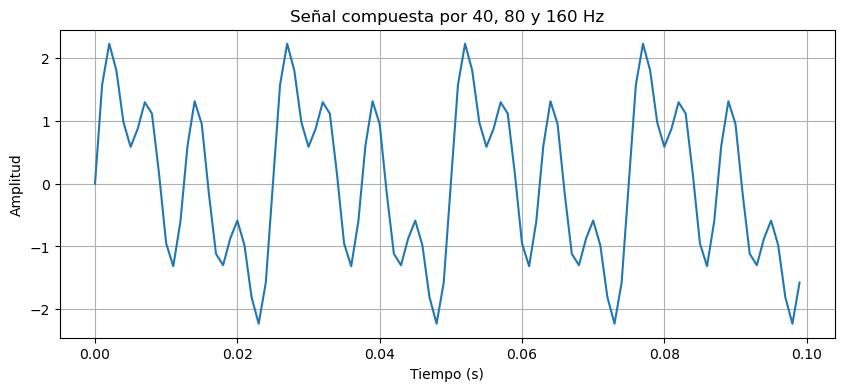

In [16]:
# Frecuencia de muestreo
Fs = 1000  # Hz
T = 1/Fs

# Duración de la señal
duracion = 0.1  # segundos

# Vector de tiempo
t = np.arange(0, duracion, T)

# Señal total
x = np.sin(2*np.pi*40*t) + np.sin(2*np.pi*80*t) + np.sin(2*np.pi*160*t)

# Gráfica
plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal compuesta por 40, 80 y 160 Hz')
plt.grid(True)
plt.show()

Para determinar la frecuencia de muestreo mínima se aplicó el teorema de Nyquist, el cual establece que la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima presente en la señal.

Dado que la frecuencia más alta es 160 Hz, la frecuencia mínima de muestreo es:

Fs = 320 Hz

Sin embargo, se seleccionó una frecuencia de muestreo de 1000 Hz para garantizar una representación adecuada de la señal y evitar aliasing.

### 2. Tranformada de fourier

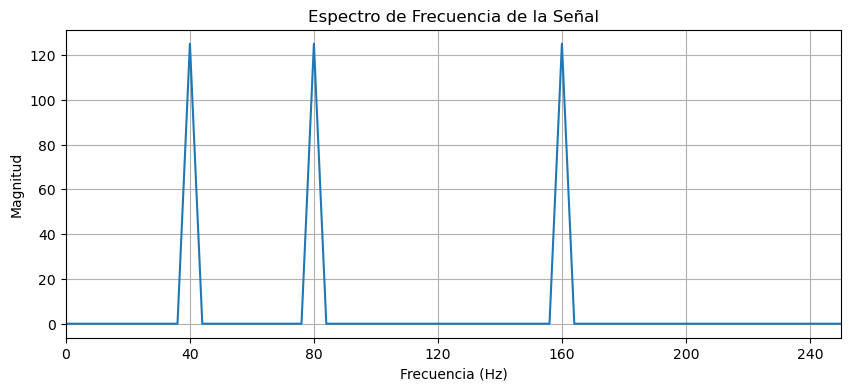

In [20]:
# Periodo fundamental
Fo = 40
To = 1/Fo

# Tiempo para 10 periodos
to = np.arange(0, 10*To, T)

x10 = np.sin(2*np.pi*40*to) + np.sin(2*np.pi*80*to) + np.sin(2*np.pi*160*to)

# FFT
X = np.fft.fft(x10)

# Número de muestras
N = len(X)

# Vector de frecuencias
F = np.arange(0, N) * Fs / N

# Mitad del espectro
Nmitad = int(np.ceil(N/2))

Fmitad = F[:Nmitad]
Xmitad = X[:Nmitad]

# Gráfica del espectro
plt.figure(figsize=(10,4))
plt.plot(Fmitad, np.abs(Xmitad))

plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.title('Espectro de Frecuencia de la Señal')

plt.xlim(0, 250)
plt.xticks(np.arange(0, 251, 40))

plt.grid(True)
plt.show()

El espectro de magnitud mostró tres componentes claramente diferenciadas ubicadas en:

- 40 Hz
- 80 Hz
- 160 Hz

lo cual confirma que la señal está compuesta por dichas frecuencias sinusoidales.

Debido a que la señal es real, el espectro presenta simetría, por lo que solo se representó la mitad positiva del espectro hasta la frecuencia de Nyquist.

### 3. Transformada inversa de fourier

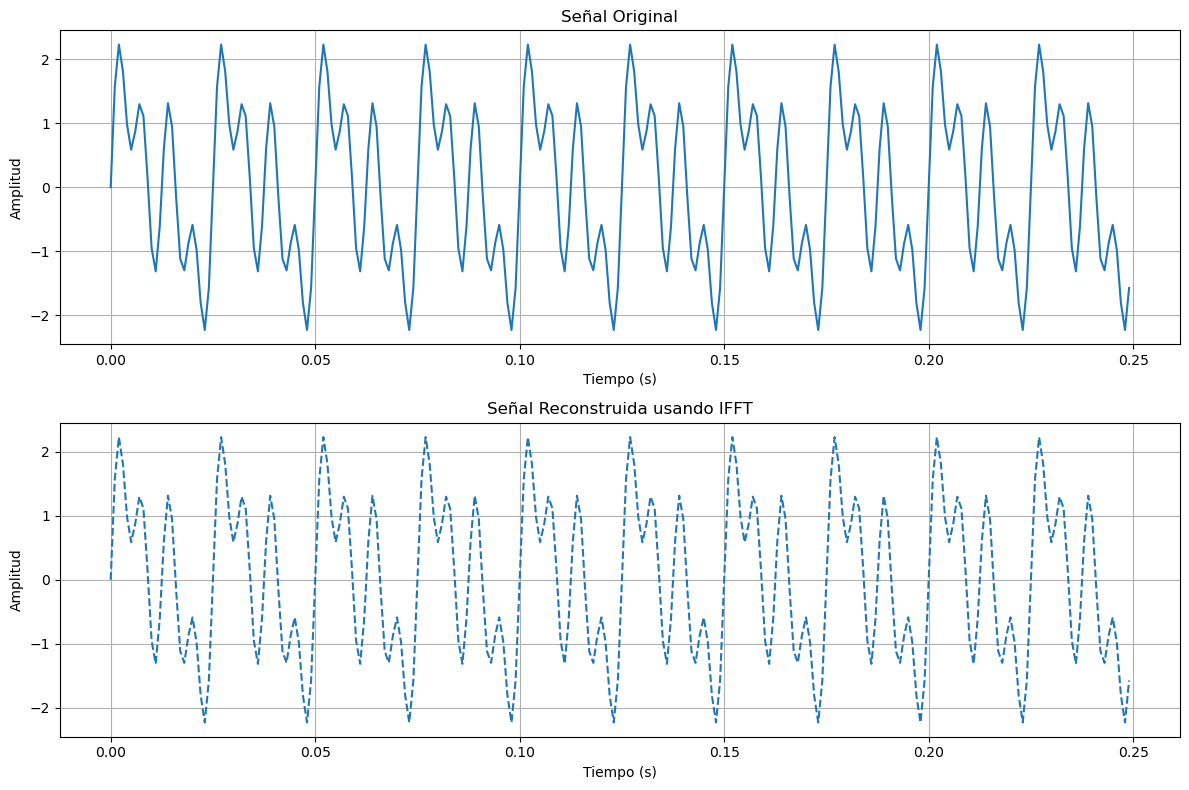

In [ ]:
# Transformada Inversa de Fourier
xr = np.fft.ifft(X)

# Figura
plt.figure(figsize=(12,8))

# Señal original
plt.subplot(2,1,1)
plt.plot(to, x10)
plt.title('Señal Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Señal reconstruida
plt.subplot(2,1,2)
plt.plot(to, np.real(xr), '--') # Solo la parte real, ya que la IFFT puede tener una pequeña componente imaginaria debido a errores numéricos
plt.title('Señal Reconstruida usando IFFT')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

La función utilizada en Python para calcular la Transformada Inversa de Fourier es:

np.fft.ifft()

Esta función pertenece al módulo numpy.fft y permite reconstruir una señal en el dominio del tiempo a partir de su representación en frecuencia obtenida con la FFT.

La IFFT devuelve valores complejos debido a pequeños errores numéricos computacionales, por lo que normalmente se utiliza únicamente la parte real de la señal:

np.real()

### 4. Filtro

Sí, estas líneas sí aplican un filtro en frecuencia.

- La señal primero es transformada al dominio de la frecuencia mediante la FFT
- Luego se crea un nuevo espectro lleno de ceros
- Después únicamente se conservan algunos coeficientes espectrales. Esto significa que solo se mantienen ciertas frecuencias de la señal original y todas las demás se eliminan.
- Finalmente, se aplica la transformada inversa para reconstruir la señal usando únicamente las frecuencias seleccionadas.

¿Qué tipo de filtro es?

Este procedimiento actúa como un Filtro pasa banda

porque deja pasar únicamente un rango pequeño de frecuencias y elimina las demás componentes espectrales.

¿Por qué funciona como filtro?

Porque en el dominio de Fourier cada posición del vector representa una frecuencia, al conservar ciertas posiciones y anular otras, se seleccionan únicamente determinadas componentes frecuenciales de la señal.

La IFFT reconstruye entonces una señal que contiene solo esas frecuencias.

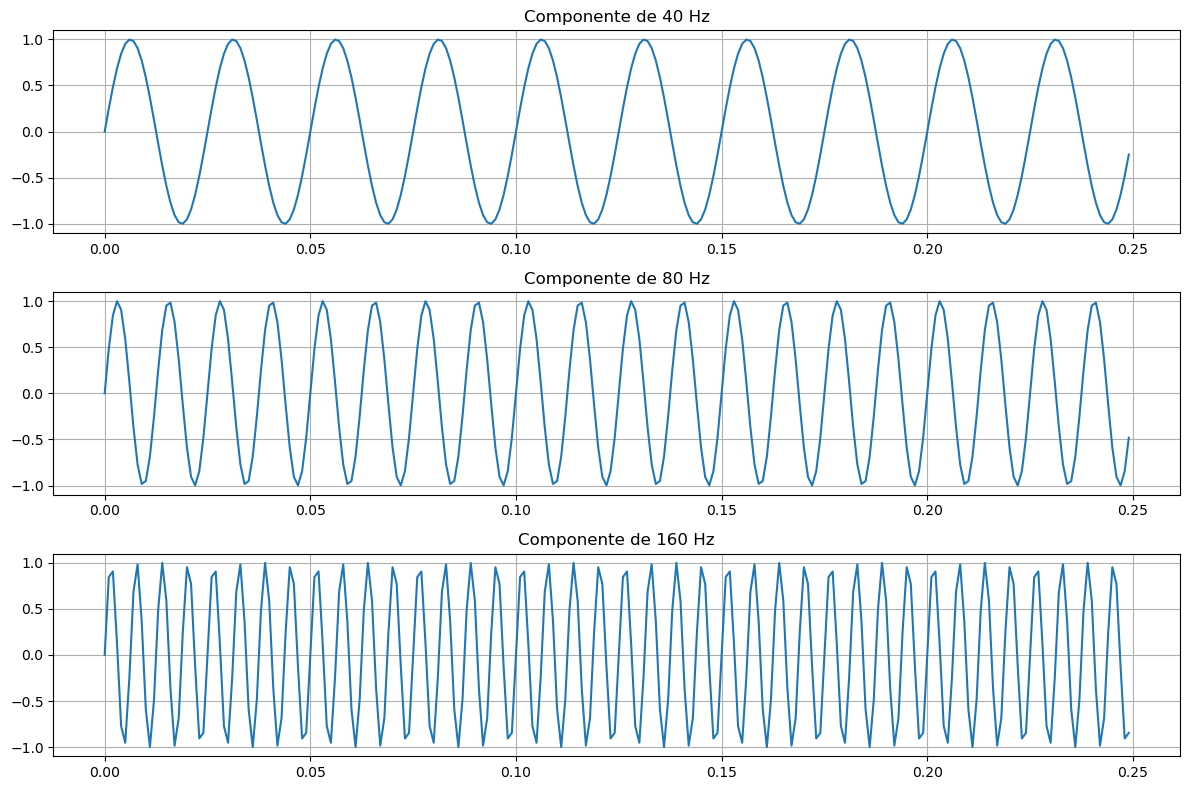

In [ ]:
# FFT de la señal
X = np.fft.fft(x10)

# Número de muestras
N = len(X)

# =========================
# Componente 40 Hz
# =========================
F40 = np.zeros(N, dtype=complex)
k1 = (40*N)/Fs # Índice correspondiente a 40 Hz

F40[int(k1)] = X[int(k1)]
F40[-int(k1)] = X[-int(k1)]

x40 = np.fft.ifft(F40)

# =========================
# Componente 80 Hz
# =========================
F80 = np.zeros(N, dtype=complex)
k2 = (80*N)/Fs # Índice correspondiente a 80 Hz

F80[int(k2)] = X[int(k2)]
F80[-int(k2)] = X[-int(k2)]

x80 = np.fft.ifft(F80)

# =========================
# Componente 160 Hz
# =========================
F160 = np.zeros(N, dtype=complex)
k3 = (160*N)/Fs # Índice correspondiente a 160 Hz

F160[int(k3)] = X[int(k3)]
F160[-int(k3)] = X[-int(k3)]

x160 = np.fft.ifft(F160)

# =========================
# Gráficas
# =========================
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(to, np.real(x40))
plt.title('Componente de 40 Hz')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(to, np.real(x80))
plt.title('Componente de 80 Hz')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(to, np.real(x160))
plt.title('Componente de 160 Hz')
plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Analisis de ECG

In [33]:
# ==========================================
# Cargar archivo .mat
# ==========================================
ruta = "C:\\Users\\david\\OneDrive\\Desktop\\Archivos Bioseñales\\senecg.mat"

mat = sio.loadmat(ruta)

# Ver variables disponibles
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ECG'])


(1250, 1)


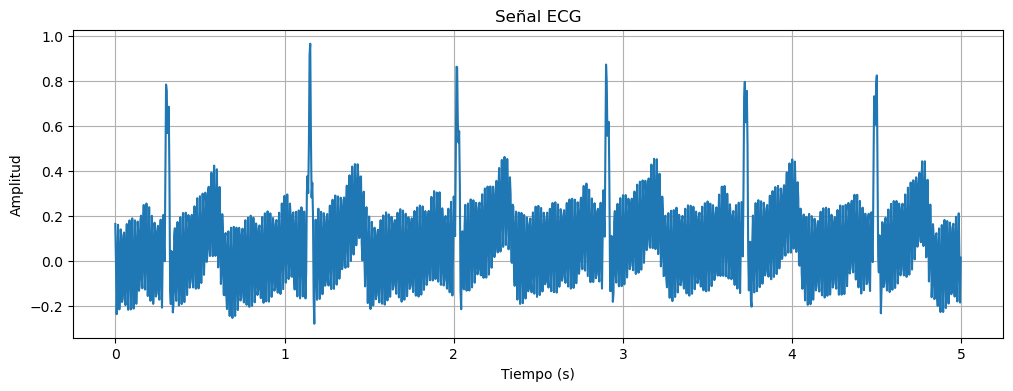

In [34]:
# ==========================================
# Extraer señal ECG
# ==========================================

ecg = mat['ECG']

# Ver dimensiones
print(ecg.shape)

# Convertir a vector 1D
ecg = ecg.flatten()

# Frecuencia de muestreo
Fs = 250  # Hz

# Vector de tiempo
t = np.arange(len(ecg)) / Fs

# ==========================================
# Graficar señal ECG
# ==========================================

plt.figure(figsize=(12,4))

plt.plot(t, ecg)

plt.title('Señal ECG')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.grid(True)
plt.show()

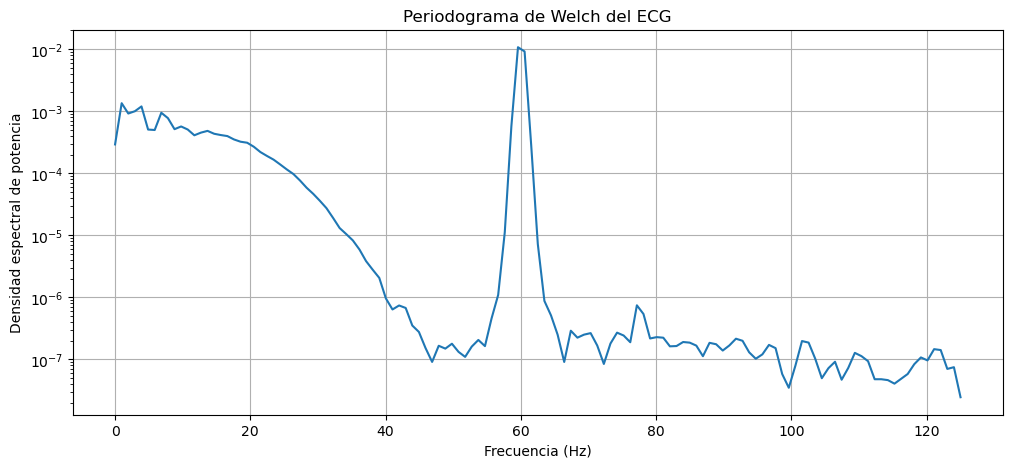

In [35]:
# ==========================================
# Periodograma de Welch
# ==========================================

# Parámetros de Welch
ventana = signal.windows.hann(256)   # Ventana Hanning
solapamiento = 128                   # 50% de solapamiento

# Welch
f, Pxx = signal.welch(
    ecg,
    fs=Fs,
    window=ventana,
    noverlap=solapamiento
)

# ==========================================
# Gráfica del periodograma
# ==========================================

plt.figure(figsize=(12,5))

plt.semilogy(f, Pxx)

plt.title('Periodograma de Welch del ECG')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')

plt.grid(True)
plt.show()

- Se utilizó una ventana Hanning porque reduce la fuga espectral y suaviza las discontinuidades en los extremos de cada segmento.
- Se escogió un solapamiento del 50% (128 muestras) ya que es una configuración estándar que mejora la estabilidad del estimador espectral sin aumentar excesivamente el costo computacional.
- El tamaño de ventana de 256 muestras permite un equilibrio adecuado entre resolución en frecuencia y resolución temporal para una señal ECG muestreada a 250 Hz.

El periodograma muestra claramente un pico muy fuerte alrededor de 60 Hz

Eso indica interferencia de la red eléctrica, que es un ruido muy común en señales ECG.

Además la mayor parte de la energía útil del ECG está por debajo de 40 Hz, mientras que el pico en 60 Hz no corresponde a actividad fisiológica del corazón.

Por lo tanto sí es necesario eliminar ruido.

Índice para 60 Hz: 300


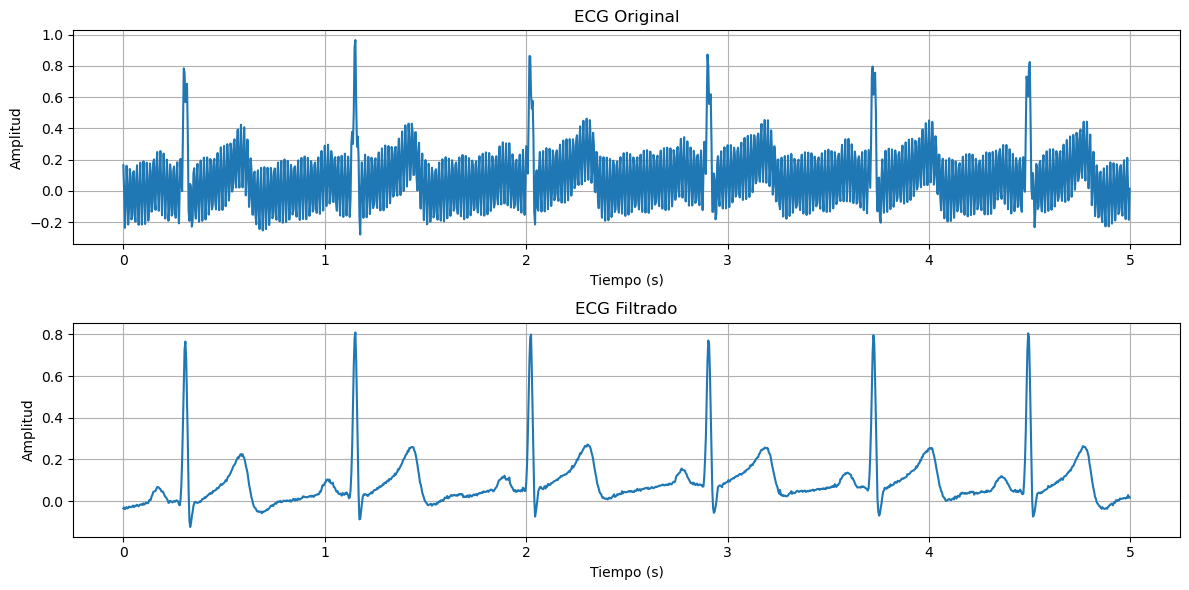

In [ ]:
# ==========================================
# FFT del ECG
# ==========================================

X = np.fft.fft(ecg)

# Número de muestras
N = len(X)

# Vector de frecuencias
F = np.arange(N) * Fs / N

# ==========================================
# Índice correspondiente a 60 Hz
# ==========================================

k60 = int(60 * N / Fs)

print("Índice para 60 Hz:", k60)

# ==========================================
# Crear copia para filtrar
# ==========================================

X_filtrado = np.copy(X)

# Eliminar componente de 60 Hz
X_filtrado[k60-1:k60+2] = 0 
X_filtrado[-k60-1:-k60+2] = 0

# ==========================================
# Reconstrucción con IFFT
# ==========================================

ecg_filtrado = np.fft.ifft(X_filtrado)

# Tomar parte real
ecg_filtrado = np.real(ecg_filtrado)

plt.figure(figsize=(12,6))

# Señal original
plt.subplot(2,1,1)
plt.plot(t, ecg)
plt.title('ECG Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Señal filtrada
plt.subplot(2,1,2)
plt.plot(t, ecg_filtrado)
plt.title('ECG Filtrado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

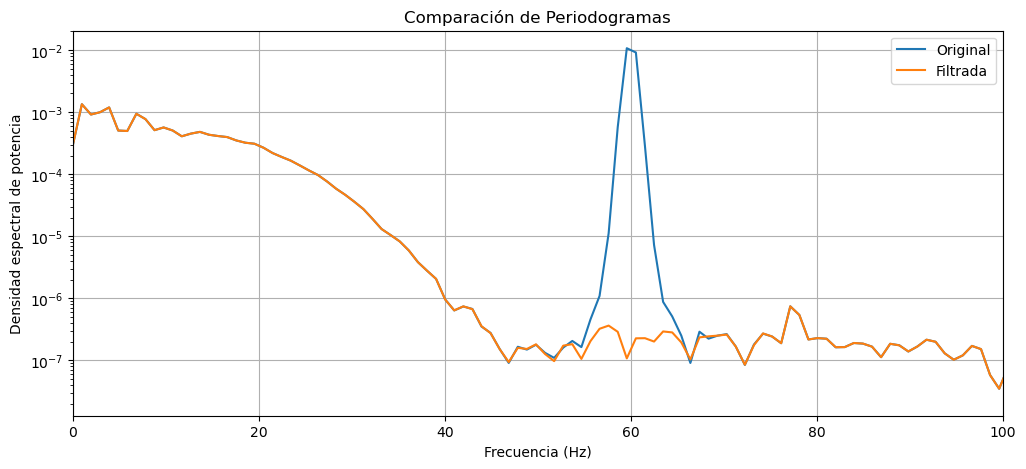

In [39]:
# ==========================================
# Welch señal filtrada
# ==========================================

f2, Pxx2 = signal.welch(
    ecg_filtrado,
    fs=Fs,
    window=ventana,
    noverlap=solapamiento
)

# ==========================================
# Comparación
# ==========================================

plt.figure(figsize=(12,5))

plt.semilogy(f, Pxx, label='Original')
plt.semilogy(f2, Pxx2, label='Filtrada')

plt.xlim(0,100)

plt.title('Comparación de Periodogramas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')

plt.legend()
plt.grid(True)

plt.show()

**Justificación del ancho de ventana**

El tamaño de la ventana fue de:

256 muestras

Como la frecuencia de muestreo es:

Fs = 250 Hz

la duración temporal de cada ventana es:

Tventana = 256/250 ≈ 1.024 s

Esta duración es adecuada para señales ECG porque permite incluir varios complejos QRS dentro de cada segmento, mejora la estimación espectral, y ofrece una resolución suficiente para identificar componentes de baja frecuencia y ruido de línea eléctrica a 60 Hz.

La resolución frecuencial obtenida es:

Δf = Fs/N = 250/256 ≈ 0.98 Hz

lo cual permite diferenciar claramente la interferencia de 60 Hz.

**Justificación del solapamiento**

Se utilizó un solapamiento del 50%: 128 muestras, porque este valor es considerado un estándar en el método de Welch.

El solapamiento aumenta el número de segmentos analizados, reduce la varianza del estimador espectral, mejora la suavidad del periodograma, y evita pérdida de información entre ventanas consecutivas.

Un 50% representa un equilibrio adecuado entre calidad espectral, estabilidad, y costo computacional.